# Best Practices for Training ANNs continued...

From last class...

# Challenges in Training ANNs

We have introduced standard MLPs, which are generally shallow networks, with just a few layers. What if you need to tackle a very complex problem, such as detecting hundreds of types of objects in high-resolution images? You may need to train a much deeper architecture, perhaps with 10 layers or much more, each containing hundreds of neurons, connected by hundreds of thousands of connections. This would not be an easy task.

1. **Vanishing gradient problem**. You would be faced with the tricky vanishing gradients problem (or the related exploding gradients problem) that affects deep neural networks and makes lower layers very hard to train. 

2. **Not enough training data**. You might not have enough training data for such a large network, or it might be too costly to label. 

3. **Training is too slow**. Training may be extremely slow. 

4. **Model has millions of parameters causing a severe risk of overfitting**. A model with millions of parameters would severely risk overfitting the training set, especially if there are not enough training instances, or they are too noisy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')

import tensorflow as tf
from tensorflow import keras

In [2]:
fashion_mnist = keras.datasets.fashion_mnist

(X_train_full, t_train_full), (X_test, t_test) = fashion_mnist.load_data()

X_train_full.shape, t_train_full.shape, X_test.shape, t_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [3]:
# Training and Validation sets
# First 5,000 samples as validation and the remaining ones as training samples
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0
t_valid, t_train = t_train_full[:5000], t_train_full[5000:]

X_test = X_test / 255.0

In [4]:
class_names = np.array(["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"])

---

# 3. Faster Optimizers

## 3.1. Gradient Descent with Momentum

Momentum optimization was first **introduced in 1964**. Recall that Gradient Descent simply updates the weights theta by directly subtracting the gradient of the cost function multiplied by the learning rate:

$$\theta^{(t+1)} \leftarrow \theta^{(t)} - \eta\nabla J(\theta^{(t)})$$

Momentum optimization cares a great deal about what previous gradients were. At each iteration, it subtracts the local gradient from the momentum vector $m$ (multiplied by the learning rate), and it updates the weights by simply adding this momentum vector. In other words, the gradient is used for acceleration, not for speed. 

$$m^{(t+1)}\leftarrow \beta m^{(t)} - \eta \nabla J(\theta^{(t)})$$

$$\theta^{(t+1)} \leftarrow \theta^{(t)} + m^{(t+1)}$$

To simulate some sort of friction mechanism and prevent the momentum from growing too large, the algorithm introduces a new hyperparameter $\beta$, simply called the **momentum**, which must be set between 0 (high friction) and 1 (no friction). A **typical momentum value is 0.9**.

* Momentum optimization will roll down the valley faster and faster until it reaches the bottom (the optimum). In deep neural networks that don't use Batch Normalization, the upper layers will often end up having inputs with very different scales, so using Momentum optimization helps a lot. It can also help roll past local optima.

Implementing momentum optimization in ```Keras``` just use the optimizer ```SGD``` and set its momentum hyperparameter:

In [5]:
optimizer = keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)

One small variant to Momentum optimization, called **Nesterov Accelerated Gradient or NAG**, proposed by Nesterov in 1983, is almost always faster than vanilla Momentum optimization. NAG measures the gradient of the cost function not at the local position but slightly ahead in the direction of the momentum, as seen in this picture. Making the convergence even faster than standard momentum.

$$m^{(t)} \leftarrow \theta^{(t)} + \mu (\theta^{(t)} - \theta^{(t-1)})$$

$$\theta^{(t+1)} \leftarrow \beta m^{(t)} - \eta \nabla J(m^{(t)})$$

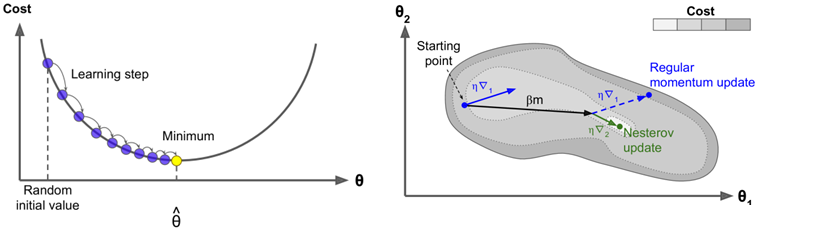

In [6]:
from IPython.display import Image
Image('figures/momentum.png',width=900)
# Source: "Hands-on machine learning with scikit-learn and tensorflow" by Geron Aurelien

In [7]:
optimizer = keras.optimizers.SGD(learning_rate=0.001, momentum=0.9, nesterov=True)

## 3.2. Gradient Descent with Adaptive Learning Rate

In addition to being able to speed up Gradient Descent, we can also **update the learning rate** to perform larger or smaller updates depending on their importance.

$$\Delta w_{ij}^{(t)} = - \eta^{(t)} \nabla J(w_{ij}^{(t)})$$

* **AdaGrad ([Adaptive Gradient algorithm, 2011](https://jmlr.org/papers/volume12/duchi11a/duchi11a.pdf))**: It simply allows the learning rate to decrease based on the parameters of the network. So it makes big updates for infrequent parameters, and small updates for frequent parameters. For this reason, it is well-suited for dealing with sparse data. Its main weakness is that its learning rate is always decreasing and decaying.

* **RMSProp ([Root Mean Squared Progagation algorithm, 2012](http://www.cs.toronto.edu/~tijmen/csc321/slides/lecture_slides_lec6.pdf)):** RMSProp is also a method in which the learning rate is adapted for each of the parameters in the network. The idea is to divide the learning rate for a parameter by a running average of the magnitudes of recent gradients for that weight.

* **Adam ([Adaptive Moment Estimation, 2015](https://arxiv.org/abs/1412.6980)):** Adam combines RMSProp and momentum learning. It is by far the most common method used today. Adam also computes adaptive learning rates for each parameter of the network. In this optimization algorithm, running averages of both the gradients and the second moments of the gradients are used.

**Adam**, or **Adaptive Moment Estimation**, was introduced in 2015. Adam is currently the standard optimization learning algorithm for training deep neural networks as it combines the ideas of **momentum optimization and adaptive learning rate**.

* Just like Momentum optimization it keeps track of an exponentially decaying average of past gradients, and it keeps track of an exponentially decaying average of past squared gradients.

Since Adam is an adaptive learning rate algorithm, it requires less tuning of the learning rate hyperparameter. You can often use the default value of eta equal to $\eta=0.001$, making Adam even easier to use than Gradient Descent.

**Nesterov Adam or Nadam** optimization, [introduced in 2016](https://openreview.net/pdf/OM0jvwB8jIp57ZJjtNEZ.pdf), is simply Adam optimization plus the Nesterov trick, so it will often converge slightly faster than Adam.

In [8]:
optimizer = keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

#beta_1 is accosicated with the delta correction rule for the momentum
# beta_2 is associated with the multiplicative decrease of learning rate

In [9]:
optimizer = keras.optimizers.Nadam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

## 3.3. Learning Rate Scheduler

One approach is to start with a large learning rate and divide it by 3 until the training algorithm stops diverging. You will not be too far from the optimal learning rate, which will learn quickly and converge to good solution.

However, you can do better than a constant learning rate: if you start with a high learning rate and then reduce it once it stops making fast progress, you can reach a good solution faster than with the optimal constant learning rate. There are many different strategies to reduce the learning rate during training. These strategies are called learning schedules. Some examples include:
1. Power scheduling, where you set the learning rate to a function of the iteration number $t$,

\begin{align*}
\eta(t) = \eta_0 / (1+t/s)^c
\end{align*}

where $c$ is typically set to $c=1$, $t$ is the iteration number and the steps $s$ are hyperparameters.

2. exponential scheduling, and
3. piecewise constant scheduling.

Implementing power scheduling with ```Keras```, set the ```decay``` hyperparameter when creating an optimizer:

In [10]:
optimizer = keras.optimizers.SGD(learning_rate=0.01, decay=1e-4)

C:\Users\aramirezsalgado\AppData\Local\anaconda3\envs\ramirez_env\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


The ```decay``` is the inverse of $s$ (the number of steps it takes to divide the learning rate) and the value for $c$ is set to default $c=1$.

---

# 4. Avoid Overfitting Through Regularization

## 4.1. L1 and L2 Regularization

Deep neural networks typically have tens of thousands of parameters, sometimes even millions. With so many parameters, the network has an incredible amount of freedom and can fit a huge variety of complex datasets. But this great flexibility also means that it is prone to overfitting the training set. 

* Regularization constraints model parameters from becoming too large

**Ridge regularizer** or **L2-Norm** adds the term $\lambda\sum_{i=1}^M w_i^2$ to the cost function during training, where $\lambda$ controls tradeoff between minimizing error term and penalty term in cost function.

**Lasso regularizer** or **L1-Norm** adds the term $\lambda\sum_{i=1}^M |w_i|$. The Lasso regularizer promotes **sparsity** of the weight vector.

**Elastic Net** adds the term $\beta\lambda\sum_{i=1}^M |w_i| + \frac{1-\beta}{2}\lambda\sum_{i=1}^M w_i^2$.

In [11]:
layer = keras.layers.Dense(100, 
                           activation='elu',
                           kernel_initializer='he_normal', 
                           kernel_regularizer=keras.regularizers.l2(0.01))

In [12]:
layer = keras.layers.Dense(100, 
                           activation='elu',
                           kernel_initializer='he_normal', 
                           kernel_regularizer=keras.regularizers.l1(0.01))

In [13]:
layer = keras.layers.Dense(100, 
                           activation='elu',
                           kernel_initializer='he_normal', 
                           kernel_regularizer=keras.regularizers.l1_l2(0.01))

## 4.2. Dropout

There are several strategies for network pruning which include:
* **Network Growing**: Start with a small MLP and add to it when unable to meet design specifications

* **Network Pruning**: Start with a large MLP and prune it by eliminating weights (driving them to zero)

* **Complexity Regularization**: Need an appropriate trade-off between reliability of training data and goodness of the model/NN architecture.

Dropout is one of the most popular regularization techniques for deep neural net works. It was proposed by Geoffrey Hinton in 2012. 

It is a fairly simple algorithm: at every training step, every neuron (including the input neurons, but always excluding the output neurons) has a probability p of being temporarily "dropped out," meaning it will be entirely ignored during this training step, but it may be active during the next step. The hyperparameter p is called the dropout rate, and it is typically set to 50%. 

After training, neurons don't get dropped anymore. That's it!

Neurons trained with dropout cannot co-adapt with their neighboring neurons; they have to be as useful as possible on their own. They also cannot rely excessively on just a few input neurons; they must pay attention to each of their input neurons. They end up being less sensitive to slight changes in the inputs. In the end you get a more robust network that generalizes better.

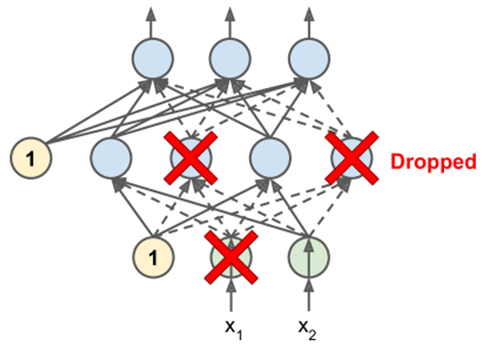

In [14]:
Image('figures/dropout.png',width=500)
# Source: "Hands-on machine learning with scikit-learn and tensorflow" by Geron Aurelien

In [15]:
model = keras.models.Sequential([ 
    keras.layers.Flatten(input_shape=[28, 28]), 
    keras.layers.Dropout(rate=0.2), 
    
    keras.layers.Dense(300, activation='elu', kernel_initializer='he_normal'), 
    keras.layers.Dropout(rate=0.2), 
    
    keras.layers.Dense(100, activation='elu', kernel_initializer='he_normal'), 
    keras.layers.Dropout(rate=0.2), 
    
    keras.layers.Dense(10, activation='softmax') 
])

C:\Users\aramirezsalgado\AppData\Local\anaconda3\envs\ramirez_env\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


* If you observe that the model is overfitting, you can increase the dropout rate. 

* Conversely, you should try decreasing the dropout rate if the model underfits the training set. 

* It can also help to increase the dropout rate for large layers, and reduce it for small ones. 

* Moreover, many state-of-the-art architectures only use dropout after the last hidden layer, so you may want to try this if full dropout is too strong.

## 4.3. Early Stopping Criteria

A very different way to regularize iterative learning algorithms such as Gradient Descent is to stop training as soon as the validation error reaches a minimum. This is called early stopping. As you can see in this figure, as the epochs go by, the algorithm learns and its prediction error (RMSE) on the training set naturally goes down, and so does its prediction error on the validation set. However, after a while the validation error stops decreasing and starts to go back up. This indicates that the model has started to overfit the training data. 

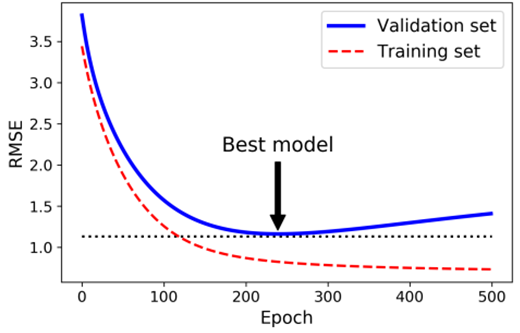

In [16]:
Image('figures/early_stopping.png',width=400)
# Source: "Hands-on machine learning with scikit-learn and tensorflow" by Geron Aurelien

In [17]:
# Fashion MNIST Dataset

fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, t_train_full), (X_test, t_test) = fashion_mnist.load_data()

# Training and Validation sets
# First 5,000 samples as validation and the remaining ones as training samples
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:15_000] / 255.0
#illustration purposes, i'm using 10k sample for training

t_valid, t_train = t_train_full[:5000], t_train_full[5000:15_000]

X_test = X_test / 255.0

This approach may result in a premature termination of learning.

an alternative is to consider the backpropagation algorithm to have converged when the Euclidean norm of the gradient vector reaches a sufficiently small threshold. However, learning may take a long time and it requires computation the norm of the gradient vector.

In [18]:
callback = keras.callbacks.EarlyStopping(monitor='val_loss', 
                                         patience=3, 
                                         restore_best_weights=True)
# This callback will stop the training when there is no improvement in
# the loss for three consecutive epochs.

In [19]:
optimizer = keras.optimizers.Adam(learning_rate=0.01, beta_1=0.9, beta_2=0.999)

model.compile(optimizer=optimizer, 
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, t_train, epochs=10, 
                    validation_data=(X_valid, t_valid),
                    callbacks=[callback])

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5311 - loss: 1.7120 - val_accuracy: 0.7806 - val_loss: 0.6206
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.7079 - loss: 0.7800 - val_accuracy: 0.8030 - val_loss: 0.5634
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7169 - loss: 0.7936 - val_accuracy: 0.7606 - val_loss: 0.7092
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7250 - loss: 0.7704 - val_accuracy: 0.7568 - val_loss: 0.7199
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7141 - loss: 0.8457 - val_accuracy: 0.7734 - val_loss: 0.6313


## Using Callbacks

It is quite common that training an neural network last hours, especially when training on large datasets. In this case, you should not only save your model at the end of training, but also save **checkpoints** at regular intervals during training, to avoid losing everything if your computer crashes. 

The ```fit()``` method accepts a callbacks argument that lets you specify a list of objects that ```Keras``` will call at the start and end of training, at the start and end of each epoch, and even before and after processing each batch.

For example, the ```ModelCheckpoint``` callback saves checkpoints of your model at regular intervals during training, by default at the **end of each epoch**

In [25]:
# build and compile the model 
checkpoint_cb = keras.callbacks.ModelCheckpoint('my_keras_model.keras')

history = model.fit(X_train, t_train, epochs=10, callbacks=[checkpoint_cb])

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7096 - loss: 0.8322
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7294 - loss: 0.7583
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7337 - loss: 0.7791
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7243 - loss: 0.7968
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7359 - loss: 0.7624
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.7569 - loss: 0.6946
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.7381 - loss: 0.7501
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7327 - loss: 0.7999
Epoch 9/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7508 - loss: 0.7333
Epoch 10/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7463 - loss: 0.7367


Moreover, if you use a validation set during training, you can set ```save_best_only=True``` when creating the ```ModelCheckpoint```. In this case, it will only save your model when its performance on the validation set is the best so far.

This is a simple way of applying **early stopping**.

In [26]:
 10_000/32

312.5

In [27]:
checkpoint_cb = keras.callbacks.ModelCheckpoint('my_keras_model.keras', 
                                                save_best_only=True)

history = model.fit(X_train, t_train, epochs=10, 
                    validation_data=(X_valid, t_valid), 
                    callbacks=[checkpoint_cb]) 

model = keras.models.load_model("my_keras_model.keras") # roll back to best model

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.7292 - loss: 0.8228 - val_accuracy: 0.7458 - val_loss: 0.8751
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.7493 - loss: 0.7724 - val_accuracy: 0.8328 - val_loss: 0.6429
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.7453 - loss: 0.7765 - val_accuracy: 0.7814 - val_loss: 0.7335
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7566 - loss: 0.7264 - val_accuracy: 0.8128 - val_loss: 0.6421
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.7573 - loss: 0.7038 - val_accuracy: 0.7948 - val_loss: 0.6965
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.7644 - loss: 0.6988 - val_accuracy: 0.8222 - val_loss: 0.7163
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.7540 - loss: 0.7350 - val_accuracy: 0.7728 - val_loss: 0.7720
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7469 - loss: 0.8103 - val_acc

Another way to implement early stopping is to simply use the ```EarlyStopping``` callback. It will interrupt training when it measures no progress on the validation set for a number of epochs (defined by the patience argument), and it will optionally roll back to the best model. 

You can combine both callbacks to save checkpoints of your model (in case your computer crashes) and interrupt training early when there is no more progress (to avoid wasting time and resources):

In [28]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=5,
                                                  monitor='val_loss',
                                                  restore_best_weights=True) 


history = model.fit(X_train, t_train, epochs=100, 
                    validation_data=(X_valid, t_valid), 
                    callbacks=[checkpoint_cb, early_stopping_cb])



Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.7339 - loss: 0.7689 - val_accuracy: 0.8170 - val_loss: 0.6408
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.7711 - loss: 0.6660 - val_accuracy: 0.8296 - val_loss: 0.8038
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7717 - loss: 0.6873 - val_accuracy: 0.8472 - val_loss: 0.6145
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7757 - loss: 0.6837 - val_accuracy: 0.8312 - val_loss: 0.6586
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.7710 - loss: 0.6766 - val_accuracy: 0.8362 - val_loss: 0.7188
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.7762 - loss: 0.7243 - val_accuracy: 0.8354 - val_loss: 0.8453
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.7639 - loss: 0.7549 - val_accuracy: 0.7930 - val_loss: 0.8036
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.7577 - loss: 0.7288 

In [29]:
checkpoint_cb = keras.callbacks.ModelCheckpoint('my_keras_model.keras', 
                                                save_best_only=True)

In [31]:
model = keras.models.load_model("my_keras_model.keras") # roll back to best model

In [32]:
history = model.fit(X_train, t_train, epochs=100, 
                    validation_data=(X_valid, t_valid), 
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.7582 - loss: 0.7042 - val_accuracy: 0.8176 - val_loss: 0.6825
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.7652 - loss: 0.6642 - val_accuracy: 0.8234 - val_loss: 0.6276
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.7706 - loss: 0.6753 - val_accuracy: 0.7774 - val_loss: 0.6789
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.7570 - loss: 0.7268 - val_accuracy: 0.8106 - val_loss: 0.6536
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.7574 - loss: 0.7202 - val_accuracy: 0.7952 - val_loss: 0.7186


The number of epochs can be set to a large value since training will stop automatically when there is no more progress.

___

# 5. Online/Stochastic, Batch and Mini-Batch Learning

The number of samples used to perform a single training iteration (forward pass + backward pass) will impact the results.

* **Online Learning** (or stochastic/sequential learning): uses one sample to update the parameters of the network.
* **Batch Learning:** uses the entire training set to update the parameters of the network.

Another way to successfully train a deep neural network is to use **mini-bath learning**. 

* As a contrast, batch learning uses the entire training data to make changes on the model parameters by using the average gradient value. The **convergence of batch learning is smooth**, as you can see in the figure below, **but it is very slow**.

* In Stochastic or **Online learning**, we use a single training instance at a time to compute the gradient and use gradient descent to make changes on the model's parameters. The **convergence for online learning is random**, by nature, so it will be **erratic** as it becomes sensitive to small differences between training instances.

**Mini-batch learning is a good compromise between the two other learning strategies**. At each step, instead of computing the gradients based on the full training set (as in Batch) or based on just one instance (as in Stochastic), Minibatch computes the gradients on small random sets of instances called minibatches. The main advantage of Mini-batch over Stochastic is that you can get a performance boost from hardware optimization of matrix operations, especially when using GPUs.

Common mini-batch sizes are 32, 64 and 128.

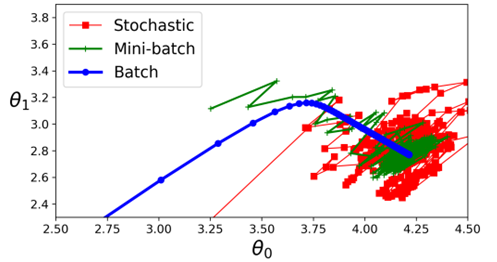

In [33]:
Image('figures/mini-batch.png',width=400)
# Source: "Hands-on machine learning with scikit-learn and tensorflow" by Geron Aurelien

In [34]:
history = model.fit(X_train, t_train, epochs=10, batch_size=1,
                    validation_data=(X_valid, t_valid))

# Online learning (1 sample/iteration)

Epoch 1/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 103s 10ms/step - accuracy: 0.2783 - loss: 6.3326 - val_accuracy: 0.2960 - val_loss: 2.8285
Epoch 2/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 91s 9ms/step - accuracy: 0.2227 - loss: 3.2852 - val_accuracy: 0.2066 - val_loss: 2.7785
Epoch 3/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 88s 9ms/step - accuracy: 0.2116 - loss: 3.7905 - val_accuracy: 0.2190 - val_loss: 2.7997
Epoch 4/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 125s 7ms/step - accuracy: 0.2137 - loss: 3.1447 - val_accuracy: 0.2480 - val_loss: 2.3966
Epoch 5/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 88s 9ms/step - accuracy: 0.2029 - loss: 3.3360 - val_accuracy: 0.1538 - val_loss: 2.5009
Epoch 6/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 177s 12ms/step - accuracy: 0.2056 - loss: 3.2730 - val_accuracy: 0.2488 - val_loss: 2.8957
Epoch 7/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 112s 9ms/step - accuracy: 0.2226 - loss: 3.2168 - val_accuracy: 0.2470 - val_loss: 2.4966
Epoch 8/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 142s 9ms/step - acc

___

# 6. Determining Whether to Gather More Data

After the first end-to-end system is established, it is time to measure the performance of the algorithm and determine how to improve it. It is often much better to gather more data than to improve the learning algorithm (or first model of choice).

How does one decide whether to gather more data?

1. Determine whether the performance on the training set is acceptable. If performance on the training set is poor, the learning algorithm is not using the training data that is already available, so there is no reason to gather more data. 
    * Instead, try adding complexity to the model by adding more layers or adding more hidden units to each layer. 
    * Also, try improving the optimization algorithm, for example by tuning the learning rate. 
    * If more complex models and carefully tuned optimization algorithms do not work well, then the problem might be the *quality* of the training data. The data may be too noisy or may not include the right inputs needed to predict the desired outputs. This suggests starting over, collecting cleaner data, or collecting a richer set of features.

2. If the performance on the training set is acceptable, then measure the performance on a test set. If the performance on the test set is also acceptable, then there is nothing left to be done. If test set performance is much worse than training set performance, then gathering more data is one of the most effective solutions. In some applications, gathering more data is simply infeasible or impossible. 
    * A simple alternative to gathering more data is to reduce the size of the model or improve regularization, by adjusting hyperparameters such as weight decay coefficients,or by adding regularization strategies such as dropout. 
    * If you find that the gap between train and test performance is still unacceptable even after tuning the regularization hyperparameters, then gathering more data is advisable.
    
3. When deciding whether to gather more data, it is also necessary to decide how much to gather. It is helpful to plot curves showing the relationship between training set size and generalization error. 
    * You can experiment with training set sizes on a logarithmic scale, for example, doubling the number of examples between consecutive experiments.

___

# Summary

We covered a wide range of techniques for training deep neural networks. The configuration provided in this table will work fine in most cases, without requiring much hyperparameter tuning.

| Hyperparameter | Default Value|
|         --     | --           |
| Kernel Initializer | LeCunn Initialization|
| Activation Function | SELU|
| Regularization    | Early stopping | 
|  Optimizer    | Adam     |
| Learning rate schedule | Performance scheduling | 
|Learning configuration | Mini-batch  |
|  Dropout | 50% |

___

# Decision Maps in MLPs

[A Neural Network Playground](https://playground.tensorflow.org/#activation=tanh&regularization=L2&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.1&regularizationRate=0&noise=10&networkShape=2&seed=0.66302&showTestData=false&discretize=false&percTrainData=80&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false) is a great tool to provide visual interpretation of MLPs performance. You can choose and interpret the effect of the use of different features, architecture size, learning rate, among others.

---